## Libraries

In [11]:
import time
import json
import requests
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from tqdm import tqdm

## Configuration

In [4]:
OLLAMA_EMBED_URL = "http://localhost:11434/api/embed"
MODEL_NAME = "embeddinggemma:300m"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device.upper()}")

Using device: CUDA


## Loading & testing dataset

In [5]:
print("Loading 'feyninc/wikipedia-500k'...")
dataset = load_dataset("feyninc/wikipedia-500k", split="train", streaming=True)

# Take 1k docs for analysis, in the end it will be 500k
print("First 1000 documents for analysis:")
documents = []
for idx, row in enumerate(dataset):
    if idx >= 1000:
        break
    
    # Empty lines protection & data structure check  
    text_content = row.get("text", row.get("paragraph", "")).strip()
    if text_content:
        documents.append({
            "id": idx,
            "title": row.get("title", f"Wikipedia Article {idx}"),
            "text": text_content
        })

print(f"Dataset is validated. Collected {len(documents)} valid objects.")

Loading 'feyninc/wikipedia-500k'...


README.md:   0%|          | 0.00/382 [00:00<?, ?B/s]

First 1000 documents for analysis:
Dataset is validated. Collected 1000 valid objects.


## Embeddings from Ollama

In [6]:
def get_ollama_embedding(text: str) -> list:
    """Request an embedding from a local model via the Ollama API"""
    payload = {
        "model": MODEL_NAME,
        "input": text
    }
    try:
        response = requests.post(OLLAMA_EMBED_URL, json=payload, timeout=10)
        response.raise_for_status()
        # Ollama returns a 2D array in the 'embeddings' key
        return response.json()["embeddings"][0]
    except Exception as e:
        print(f"\nOllama request error: {e}")
        return [0.0] * 768 # Return a zero vector on error

# MAY BE TOO SLOW DUE HTTP REQUESTS
print("Generating embeddings for documents (Iteration 1 - FP32)...")
raw_embeddings = []
latencies = []

# Measuring embedding generation speed
for doc in tqdm(documents, desc="Encoding documents"):
    start_time = time.time()
    vector = get_ollama_embedding(doc["text"])
    latencies.append((time.time() - start_time) * 1000) # ms
    raw_embeddings.append(vector)

# Convert to NumPy matrix (Shape: N x 768)
embeddings_matrix = np.array(raw_embeddings, dtype=np.float32)
print(f"Embedding matrix created. Shape: {embeddings_matrix.shape} (Float32)")

Generating embeddings for documents (Iteration 1 - FP32)...


Encoding documents:   3%|▎         | 32/1000 [01:45<53:00,  3.29s/it] 

KeyboardInterrupt



In [12]:
# Version with batch loading

def get_ollama_embeddings_batch(texts: list) -> list:
    """Request vectors for an ENTIRE BATCH of texts via the Ollama API"""
    payload = {
        "model": MODEL_NAME,
        "input": texts  # Send a list of strings instead of a single string
    }
    try:
        response = requests.post(OLLAMA_EMBED_URL, json=payload, timeout=60)
        response.raise_for_status()
        # Ollama returns a 2D array of vectors in the 'embeddings' key
        return response.json()["embeddings"]
    except Exception as e:
        print(f"\nBatch request error: {e}")
        # In case of an error, return zero vectors for the entire batch
        return [[0.0] * 768 for _ in range(len(texts))]

BATCH_SIZE = 256
TOTAL_DOCS = len(documents)
raw_embeddings = []
latencies = []

print(f"Generating embeddings using Batched Inference (Batch Size: {BATCH_SIZE})...")

# Measure execution time per batch using perf_counter
for i in tqdm(range(0, TOTAL_DOCS, BATCH_SIZE), desc="Encoding batches"):
    batch_docs = documents[i : i + BATCH_SIZE]
    batch_texts = [doc["text"] for doc in batch_docs]
    
    # Start wall-clock timer
    start_time = time.perf_counter()
    
    vectors = get_ollama_embeddings_batch(batch_texts)
    
    end_time = time.perf_counter()
    
    # Calculate latency for the entire batch
    latencies.append((end_time - start_time) * 1000)  # ms
    raw_embeddings.extend(vectors)

# Convert to NumPy matrix (Shape: N x 768)
embeddings_matrix = np.array(raw_embeddings, dtype=np.float32)
print(f"Embedding matrix created. Shape: {embeddings_matrix.shape} (Float32)")

Generating embeddings using Batched Inference (Batch Size: 256)...


Encoding batches: 100%|██████████| 4/4 [01:30<00:00, 22.52s/it]

Embedding matrix created. Shape: (1000, 768) (Float32)


## The math behind exact search (brute-force kNN)

In [17]:
# Move matrix to GPU via PyTorch for instant matrix multiplication
db_vectors_gpu = torch.tensor(embeddings_matrix, device=device)

def run_semantic_search(query_text: str, top_k: int = 3):
    """Exact Brute-Force Search via Cosine Similarity on GPU"""
    # 1. Get the query vector
    query_vector = get_ollama_embedding(query_text)
    query_tensor = torch.tensor(query_vector, device=device).unsqueeze(0) # Shape (1, 768)
    
    # 2. Cosine Similarity: (A * B) / (||A|| * ||B||)
    query_norm = query_tensor / query_tensor.norm(dim=1, keepdim=True)
    db_norm = db_vectors_gpu / db_vectors_gpu.norm(dim=1, keepdim=True)
    
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_search = time.perf_counter()
    
    # GPU matmul
    scores = torch.mm(query_norm, db_norm.transpose(0, 1)).squeeze(0)
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    search_time = (time.perf_counter() - start_search) * 1000
    
    # Get top-K nearest neighbors
    top_scores, top_indices = torch.topk(scores, top_k)
    
    results = []
    for score, idx in zip(top_scores.cpu().numpy(), top_indices.cpu().numpy()):
        results.append({
            "doc": documents[idx],
            "score": float(score)
        })
    return results, search_time

## Thematic Analysis of Extractions (Examples)

In [19]:
print("Validating knowledge extraction across various domains...")

test_topics = [
    "Space exploration, planets, rockets and NASA missions", 
    "Computer programming, software development, design patterns and source code",
    "Ancient history, Roman Empire, emperors and military battles"
]

search_latencies = []

for topic in test_topics:
    print(f"\n[Topic Query]: '{topic}'")
    matches, s_time = run_semantic_search(topic, top_k=2)
    search_latencies.append(s_time)
    
    for rank, match in enumerate(matches, 1):
        print(f"{rank}. Title: {match['doc']['title']} | Similarity Score: {match['score']:.4f}")
        print(f"Text: {match['doc']['text'][:120]}...")

Validating knowledge extraction across various domains...

[Topic Query]: 'Space exploration, planets, rockets and NASA missions'
1. Title: Astronaut | Similarity Score: 0.3446
Text: An astronaut (from the Ancient Greek  (), meaning 'star', and  (), meaning 'sailor') is a person trained, equipped, and ...
2. Title: Apollo program | Similarity Score: 0.3424
Text: The Apollo program, also known as Project Apollo, was the United States human spaceflight program carried out by the Nat...

[Topic Query]: 'Computer programming, software development, design patterns and source code'
1. Title: Ada (programming language) | Similarity Score: 0.3338
Text: Ada is a structured, statically typed, imperative, and object-oriented high-level programming language, inspired by Pasc...
2. Title: Array (data structure) | Similarity Score: 0.3093
Text: In computer science, an array is a data structure consisting of a collection of elements (values or variables), of same ...

[Topic Query]: 'Ancient history,

## Metrics Benchmarking and Statistics (Plots)


Average generation latency per embedding: 22523.71 ms
GPU Search latency (RTX 3080): 0.1448 ms
Raw vector matrix memory footprint: 2.9297 MB

All plots saved to 'iteration_1_analysis.png'.


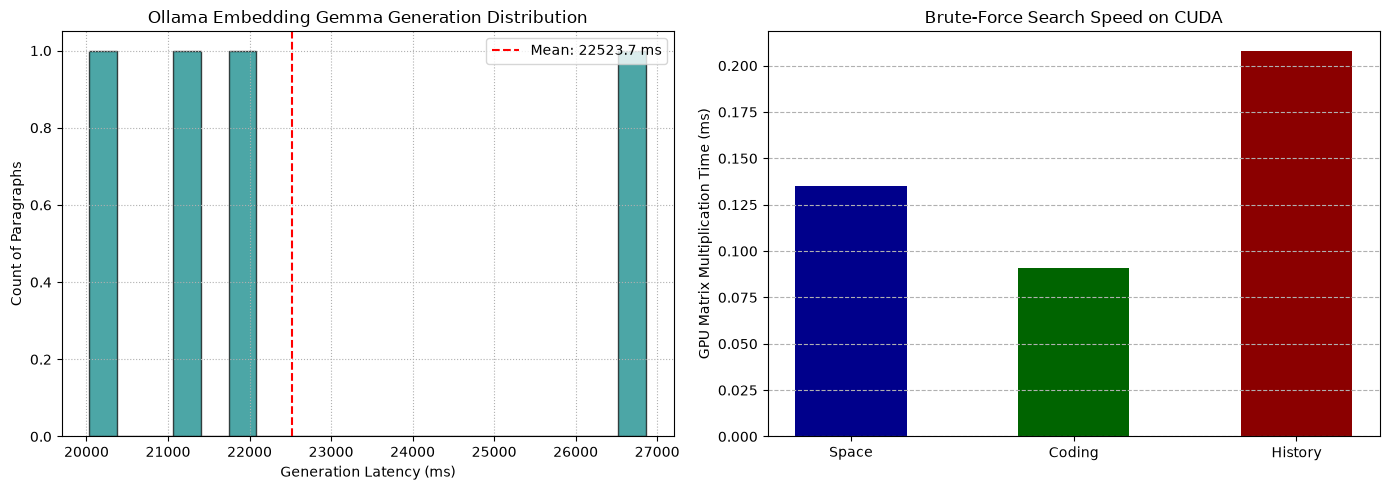

In [20]:
print("Collecting performance metrics for Iteration 1...")

# Calculate memory usage of the matrix in RAM
matrix_memory_mb = embeddings_matrix.nbytes / (1024 ** 2)
# Measure allocated VRAM (if GPU is being used)
vram_allocated = torch.cuda.memory_allocated(device) / (1024 ** 2) if device == "cuda" else 0

print(f"Average generation latency per embedding: {np.mean(latencies):.2f} ms")
print(f"GPU Search latency (RTX 3080): {np.mean(search_latencies):.4f} ms")
print(f"Raw vector matrix memory footprint: {matrix_memory_mb:.4f} MB")

# Plotting diagnostic analysis charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Vector generation latency distribution
ax1.hist(latencies, bins=20, color='teal', edgecolor='black', alpha=0.7)
ax1.axvline(np.mean(latencies), color='red', linestyle='--', label=f'Mean: {np.mean(latencies):.1f} ms')
ax1.set_xlabel('Generation Latency (ms)')
ax1.set_ylabel('Count of Paragraphs')
ax1.set_title('Ollama Embedding Gemma Generation Distribution')
ax1.legend()
ax1.grid(True, linestyle=':')

# Plot 2: Exact search speed across different topics
topics_labels = ["Space", "Coding", "History"]
ax2.bar(topics_labels, search_latencies, color=['darkblue', 'darkgreen', 'darkred'], width=0.5)
ax2.set_ylabel('GPU Matrix Multiplication Time (ms)')
ax2.set_title('Brute-Force Search Speed on CUDA')
ax2.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig("iteration_1_analysis.png")
print("\nAll plots saved to 'iteration_1_analysis.png'.")
plt.show()
